# 02 · EDA: how slow is justice in Maharashtra?

Week 2 exploratory analysis of 10M district-court cases filed 2010–2018. Every duration figure
uses **Kaplan-Meier** on right-censored durations (D-002), because a decided-only average
leaves out the slowest cases, which are the ones still pending. Rows with `bad_dates` (decision
before filing, 0.5%) are dropped.

Figures are saved to `reports/figures/`.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mt
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter

from court_delay.config import PROCESSED, RAW, ROOT

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Reference palette (dataviz skill), light mode. Validated: blue/orange pass all CVD checks.
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
BLUE, ORANGE, MUTED = "#2a78d6", "#eb6834", "#a9a8a3"
GROUP = {1: ("Criminal", BLUE), 0: ("Civil", ORANGE)}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 160, "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "lines.linewidth": 2, "legend.frameon": False,
})

def finish(fig, name, source=True):
    if source:
        fig.text(0.01, -0.03, "Source: Development Data Lab e-Courts data, Maharashtra cases filed 2010–2018. "
                 "Kaplan-Meier on right-censored durations.", fontsize=7.5, color=INK2)
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")
    plt.show()

def km(df):
    return KaplanMeierFitter().fit(df["duration_days"], df["event"])

def km_median(df):
    return km(df).median_survival_time_

def km_decided_by(df, days):
    """Share decided within `days` (1 - S(days))."""
    return 1 - km(df).survival_function_at_times(days).iloc[0]

df = pd.read_parquet(PROCESSED / "cases_maharashtra.parquet", columns=[
    "year", "dist_code", "court_no", "district_name", "case_category", "is_criminal",
    "filing_date", "decision_date", "event", "duration_days", "bad_dates"])
df = df[~df["bad_dates"]].drop(columns="bad_dates").reset_index(drop=True)
df["case_category"] = df["case_category"].astype("category")
print(f"{len(df):,} cases, {1 - df.event.mean():.1%} pending (censored)")

10,007,058 cases, 27.6% pending (censored)


## 1. The headline: how long does a case take?

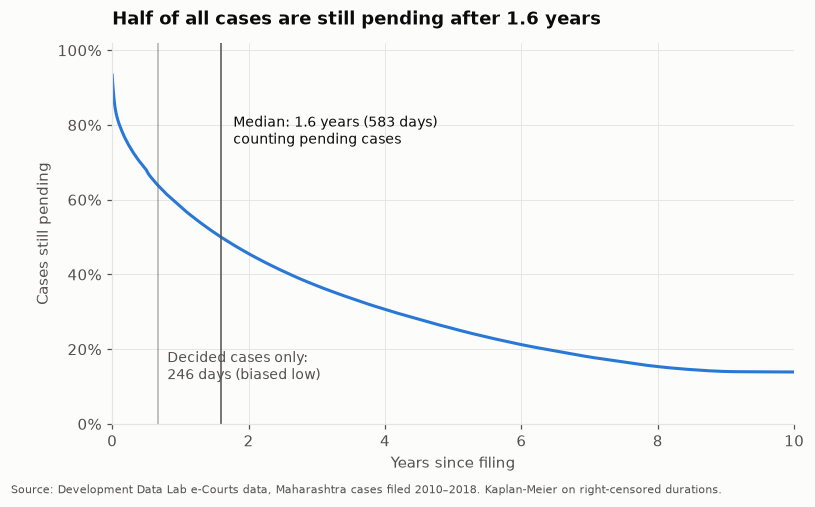

KM median 583 days vs decided-only median 246
pending after 1 year(s): 58.2%
pending after 3 year(s): 37.0%
pending after 5 year(s): 25.5%


In [2]:
all_km = km(df)
km_med = all_km.median_survival_time_
naive_med = df.loc[df.event == 1, "duration_days"].median()
s = all_km.survival_function_.iloc[:, 0]
s = s[s.index <= 3650]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(s.index / 365.25, s.values, color=BLUE)
ax.axvline(km_med / 365.25, color=INK2, lw=1)
ax.axvline(naive_med / 365.25, color=INK2, lw=1, alpha=.45)
ax.annotate(f"Median: {km_med/365.25:.1f} years ({km_med:.0f} days)\ncounting pending cases",
            (km_med / 365.25, .75), xytext=(8, 0), textcoords="offset points", fontsize=9, color=INK)
ax.annotate(f"Decided cases only:\n{naive_med:.0f} days (biased low)",
            (naive_med / 365.25, .12), xytext=(6, 0), textcoords="offset points",
            fontsize=9, color=INK2)
ax.set_ylim(0, 1.02); ax.set_xlim(0, 10)
ax.yaxis.set_major_formatter(mt.PercentFormatter(1))
ax.set_xlabel("Years since filing"); ax.set_ylabel("Cases still pending")
ax.set_title("Half of all cases are still pending after %.1f years" % (km_med / 365.25))
finish(fig, "01_km_overall")
print(f"KM median {km_med:.0f} days vs decided-only median {naive_med:.0f}")
for y in (1, 3, 5):
    print(f"pending after {y} year(s): {all_km.survival_function_at_times(365.25*y).iloc[0]:.1%}")

Taking the median over decided cases only gives a much shorter figure, because the cases still
pending (27%) are the slow ones. Kaplan-Meier counts each pending case as "at least this long".

## 2. Pending share by filing year

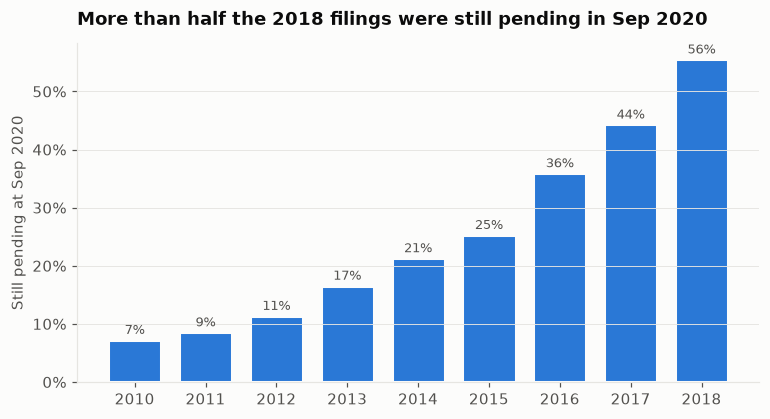

In [3]:
pend = 1 - df.groupby("year")["event"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pend.index, pend.values, color=BLUE, width=0.75, edgecolor=SURFACE, linewidth=2)
for x, v in pend.items():
    ax.text(x, v + .01, f"{v:.0%}", ha="center", fontsize=8.5, color=INK2)
ax.set_xticks(pend.index)
ax.yaxis.set_major_formatter(mt.PercentFormatter(1))
ax.grid(axis="x", visible=False)
ax.set_ylabel("Still pending at Sep 2020")
ax.set_title("More than half the 2018 filings were still pending in Sep 2020")
finish(fig, "02_pending_by_year", source=False)

Recent cohorts have had less time to finish, so this chart shows **exposure** as well as
slowness. Comparing years fairly needs a fixed horizon (section 6).

## 3. Case type matters most

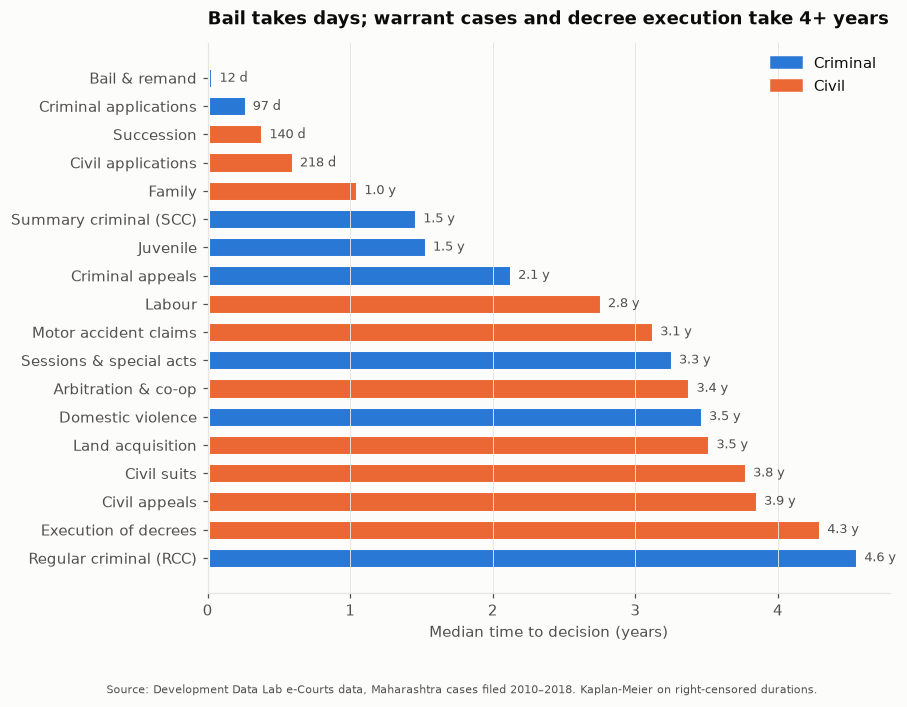

,label,n,pending,median
1,Bail & remand,437436,0.003,12.0
6,Criminal applications,1240298,0.124,97.0
16,Succession,29605,0.093,140.0
3,Civil applications,426332,0.160,218.0
9,Family,373623,0.169,383.0
17,Summary criminal (SCC),3749458,0.251,534.0
10,Juvenile,50743,0.224,559.0
5,Criminal appeals,163276,0.269,777.0
11,Labour,159693,0.309,1007.0
13,Motor accident claims,266585,0.309,1141.0


In [4]:
rows = []
for cat, g in df.groupby("case_category", observed=True):
    if cat == "other":
        continue
    rows.append({"category": cat, "n": len(g), "criminal": int(g["is_criminal"].iloc[0]),
                 "median": km_median(g), "pending": 1 - g.event.mean()})
cat = pd.DataFrame(rows).sort_values("median")
NICE = {"bail_remand": "Bail & remand", "criminal_misc": "Criminal applications",
        "succession": "Succession", "civil_misc": "Civil applications", "family": "Family",
        "summary_criminal": "Summary criminal (SCC)", "juvenile": "Juvenile",
        "criminal_appeal_revision": "Criminal appeals", "labour": "Labour",
        "motor_accident": "Motor accident claims", "sessions_special": "Sessions & special acts",
        "arbitration_cooperative": "Arbitration & co-op", "domestic_violence": "Domestic violence",
        "land_acquisition": "Land acquisition", "civil_suit": "Civil suits",
        "civil_appeal_revision": "Civil appeals", "execution": "Execution of decrees",
        "regular_criminal": "Regular criminal (RCC)"}
cat["label"] = cat["category"].map(NICE)

fig, ax = plt.subplots(figsize=(8, 6.5))
y = np.arange(len(cat))
ax.barh(y, cat["median"] / 365.25, color=[GROUP[c][1] for c in cat["criminal"]],
        height=0.72, edgecolor=SURFACE, linewidth=2)
for yi, (m, n) in enumerate(zip(cat["median"], cat["n"])):
    txt = f"{m:.0f} d" if m < 365 else f"{m/365.25:.1f} y"
    ax.text(m / 365.25 + .05, yi, txt, va="center", fontsize=8.5, color=INK2)
ax.set_yticks(y, cat["label"]); ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("Median time to decision (years)")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for _, c in GROUP.values()],
          labels=[l for l, _ in GROUP.values()], loc="upper right")
ax.set_title("Bail takes days; warrant cases and decree execution take 4+ years")
finish(fig, "03_median_by_category")
cat[["label", "n", "pending", "median"]].round(3)

## 4. Civil vs criminal

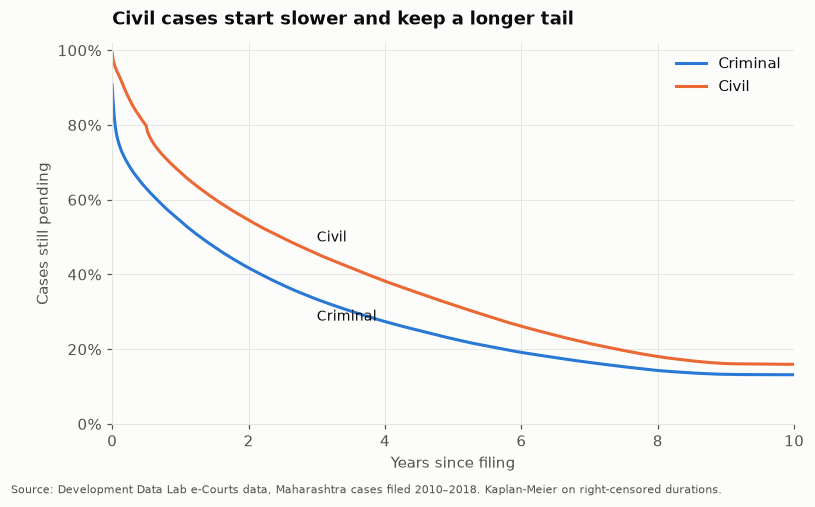

{'Criminal': '473 days', 'Civil': '905 days'}
{np.int8(1): 0.702, np.int8(0): 0.298}


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
meds = {}
for flag, (name, color) in GROUP.items():
    k = km(df[df.is_criminal == flag])
    sf = k.survival_function_.iloc[:, 0]
    sf = sf[sf.index <= 3650]
    ax.plot(sf.index / 365.25, sf.values, color=color, label=name)
    meds[name] = k.median_survival_time_
    y3 = sf.asof(3 * 365.25)
    ax.annotate(name, (3, y3), xytext=(0, 8 if flag == 0 else -14), textcoords="offset points",
                color=INK, fontsize=9)
ax.set_ylim(0, 1.02); ax.set_xlim(0, 10)
ax.yaxis.set_major_formatter(mt.PercentFormatter(1))
ax.set_xlabel("Years since filing"); ax.set_ylabel("Cases still pending")
ax.legend(loc="upper right")
ax.set_title("Civil cases start slower and keep a longer tail")
finish(fig, "04_km_civil_vs_criminal")
print({k: f"{v:.0f} days" for k, v in meds.items()})
print(df.is_criminal.value_counts(normalize=True).round(3).to_dict())

## 5. Districts

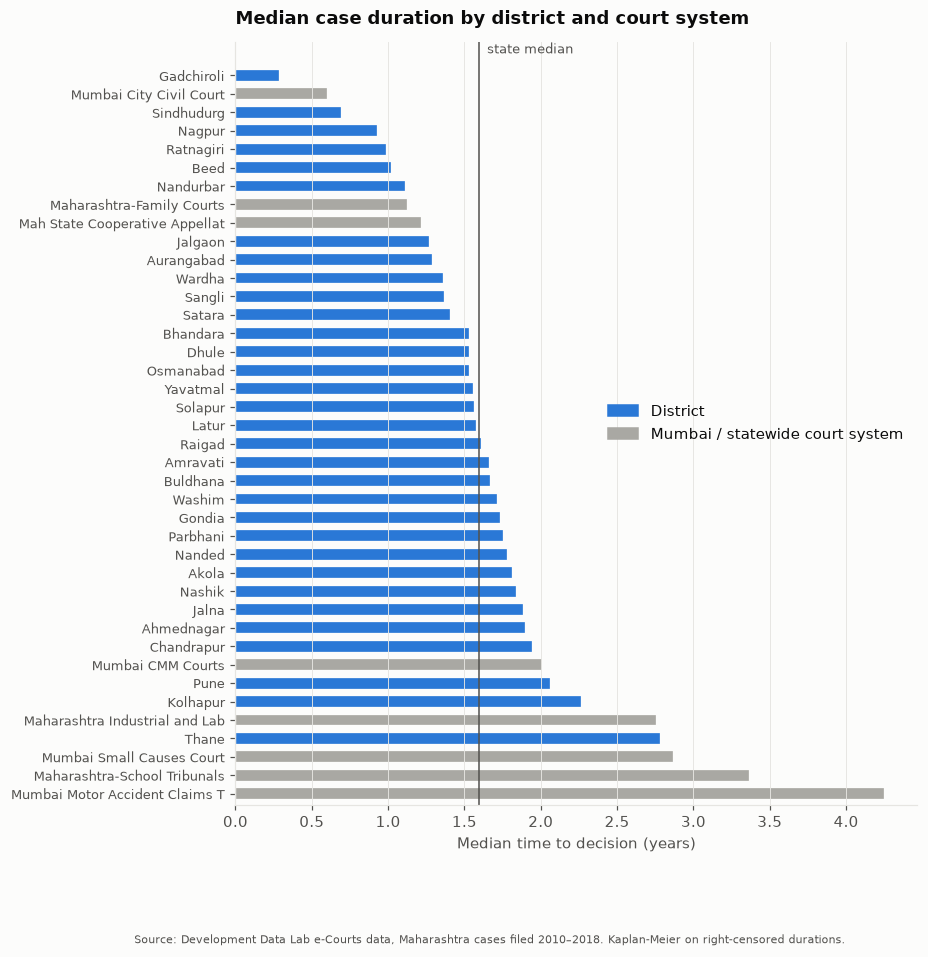

,district,n,median,pending,criminal_share,court_system
9,Gadchiroli,64611,107.0,0.102,0.874,False
20,Mumbai City Civil Court,335725,222.0,0.232,0.674,True
34,Sindhudurg,50914,254.0,0.193,0.674,False
23,Nagpur,638737,341.0,0.240,0.810,False
31,Ratnagiri,85798,362.0,0.202,0.709,False
4,Beed,310236,374.0,0.212,0.586,False
25,Nandurbar,69233,407.0,0.194,0.754,False
17,Maharashtra-Family Courts,192249,412.0,0.169,0.000,True
15,Mah State Cooperative Appellat,35752,446.0,0.248,0.000,True
11,Jalgaon,326421,466.0,0.180,0.723,False


In [6]:
rows = [{"district": d, "n": len(g), "median": km_median(g), "pending": 1 - g.event.mean(),
         "criminal_share": g.is_criminal.mean()}
        for d, g in df.groupby("district_name")]
dist = pd.DataFrame(rows).sort_values("median")
# DDL's "district" list includes Mumbai's court systems and statewide tribunals, which each
# hear only one kind of case. Show them apart from the geographic districts.
dist["court_system"] = dist["district"].str.match(r"^(Mumbai|Maharashtra|Mah )")

fig, ax = plt.subplots(figsize=(8, 9))
y = np.arange(len(dist))
ax.barh(y, dist["median"] / 365.25, color=np.where(dist["court_system"], MUTED, BLUE),
        height=0.7, edgecolor=SURFACE, linewidth=1.5)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in (BLUE, MUTED)],
          labels=["District", "Mumbai / statewide court system"], loc="center right")
ax.axvline(km_med / 365.25, color=INK2, lw=1)
ax.text(km_med / 365.25, -1.2, "  state median", fontsize=8.5, color=INK2)
ax.set_yticks(y, dist["district"], fontsize=8.5); ax.invert_yaxis()
ax.set_ylim(len(dist) - .4, -1.8)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Median time to decision (years)")
ax.set_title("Median case duration by district and court system")
finish(fig, "05_median_by_district")
dist.round(3)

District medians mix speed with **case mix**: a district with many fast bail or SCC matters looks
quick. Week 3's Cox model compares districts after adjusting for case category. Check the
correlation between `criminal_share` and `median` below before reading too much into the ranking.

In [7]:
print("corr(median, criminal_share):", round(dist["median"].corr(dist["criminal_share"]), 2))

corr(median, criminal_share): -0.5


## 6. Trend: share decided within one year, by filing year

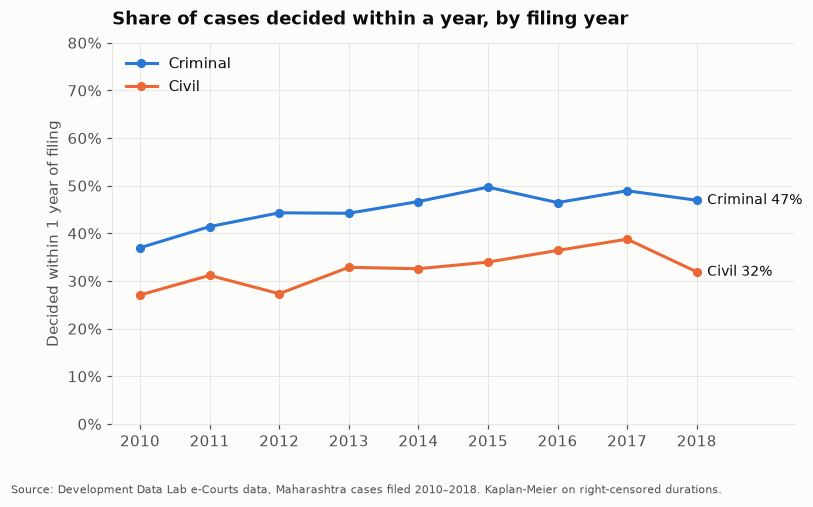

is_criminal,civil,criminal
year,,
2010,0.271,0.370
2011,0.312,0.414
2012,0.273,0.443
2013,0.329,0.442
2014,0.326,0.467
2015,0.340,0.497
2016,0.364,0.465
2017,0.388,0.489
2018,0.319,0.470


In [8]:
# A fixed 1-year horizon is observable for every cohort (cutoff Sep 2020 > Dec 2018 + 1y),
# so unlike the pending share this is a fair comparison across years.
trend = (df.groupby(["year", "is_criminal"])
           .apply(lambda g: km_decided_by(g, 365), include_groups=False)
           .unstack())
fig, ax = plt.subplots(figsize=(8, 4.5))
for flag, (name, color) in GROUP.items():
    ax.plot(trend.index, trend[flag], color=color, marker="o", ms=5, label=name)
    ax.text(trend.index[-1] + .15, trend[flag].iloc[-1], f"{name} {trend[flag].iloc[-1]:.0%}",
            color=INK, fontsize=9, va="center")
ax.set_xticks(trend.index); ax.set_xlim(2009.6, 2019.4)
ax.set_ylim(0, max(.8, trend.max().max() + .05))
ax.yaxis.set_major_formatter(mt.PercentFormatter(1))
ax.set_ylabel("Decided within 1 year of filing")
ax.legend(loc="upper left")
ax.set_title("Share of cases decided within a year, by filing year")
finish(fig, "06_trend_1yr")
trend.rename(columns={1: "criminal", 0: "civil"}).round(3)

## 7. Slowest courts (table)

In [9]:
ck = pd.read_csv(RAW / "keys" / "cases_court_key.csv")
ck = (ck[ck.state_code == 1].sort_values("year")
        .drop_duplicates(["dist_code", "court_no"], keep="last")[["dist_code", "court_no", "court_name"]])
rows = [{"dist_code": d, "court_no": c, "n": len(g), "median": km_median(g),
         "pending": 1 - g.event.mean(), "criminal_share": g.is_criminal.mean()}
        for (d, c), g in df.groupby(["dist_code", "court_no"]) if len(g) >= 5000]
courts = pd.DataFrame(rows).merge(ck, how="left").sort_values("median", ascending=False)
print(f"{len(courts)} courts with >= 5,000 cases")
courts.head(15)[["court_name", "n", "median", "pending", "criminal_share"]].round(2)

479 courts with >= 5,000 cases


,court_name,n,median,pending,criminal_share
241,"CIVIL COURT J. D., VASAI",34889,inf,0.64,0.82
249,"Judicial Magistrate First Class, III Court, Ka...",18016,inf,0.58,1.00
46,"Civil And Criminal Court, Sindkhed Raja",5513,2509.0,0.60,0.88
248,"Judicial Magistrate First Class, Ist Court, Ka...",19808,2086.0,0.53,1.00
234,CIVIL COURT J.D. KALYAN,10017,2075.0,0.49,0.00
229,J.M.F.C. Ist COURT THANE,32538,2050.0,0.50,1.00
265,"ADDL.CHIEF METROPOLITAN MAGISTRATE, DADAR, MUM...",41113,1872.0,0.50,1.00
242,Civil Judge J.D. JMFC Vashi,49109,1712.0,0.48,0.82
394,ADDITIONAL DISTRICT AND SESSIONS JUDGE KARAD,8541,1645.0,0.45,0.36
326,Senior Division Court Newasa,8546,1619.0,0.48,0.00


Court establishments, not judges (D-006). An infinite median means fewer than half of that
court's cases had been decided by the cutoff.

## Findings

1. **The median case takes 583 days (1.6 years)** to decide once pending cases are counted.
   The decided-only median is 246 days, which understates it by 2.4×. After 1, 3 and 5 years,
   58%, 37% and 26% of cases are still pending.
2. **Case type dominates.** Kaplan-Meier medians run from 12 days (bail) to 4.6 years (RCC warrant
   cases). Executing a decree (4.3 years) takes longer than the civil suit that produced it
   (3.8 years).
3. **Civil is slower than criminal**: medians of 905 and 473 days. 70% of cases are criminal.
4. **Districts range from 0.3 years (Gadchiroli) to 2.8 years (Thane).** Rankings are confounded
   by case mix (the correlation between district median and criminal share is −0.5), so compare
   adjusted districts in the Week 3 Cox model. Eight "districts" are really Mumbai court systems
   or statewide tribunals (MACT Mumbai is slowest at 4.3 years).
5. **Speed is improving slowly.** Measured over a fixed one-year horizon, so every cohort is
   compared fairly, the share decided within a year rose from 37% to 47% for criminal cases and
   from 27% to 32–39% for civil cases between 2010 and 2018.
6. **Curve features:**
   - A jump at day 182 comes from family judgements, matching the 6-month cooling-off period for
     mutual-consent divorce.
   - After 9 years the curve flattens at about 14% still pending. 112k cases are at risk past
     9 years, but only 829 (0.7%) of them are decided, which suggests stale or abandoned records.
     This matters for parametric fits.
7. **Slowest courts** (≥5,000 cases): two courts in Vasai and Kalyan had decided fewer than half
   their cases by the cutoff, so their KM median is undefined.

Not done yet: the slowest acts and sections, which need `acts_sections`.
